# Tutorial 5: SquiDiff Enables Virtual Section Reconstruction of Planarians

SquiDiff learns a conditional diffusion model over spatial transcriptomics
data and generates *virtual sections* — synthetic expression profiles at
timepoints between experimental observations — by decoding along a learned
temporal direction in latent space.

**Five-step analysis:** &nbsp; (1) latent visualisation &nbsp;→&nbsp;
(2) joint raw + simulated manifold &nbsp;→&nbsp;
(3) pairwise cell-type distance curves &nbsp;→&nbsp;
(4) river plots, heatmaps & networks &nbsp;→&nbsp;
(5) transcriptional activity dynamics in gene space.

In [1]:
import os, sys, warnings, json
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import anndata, scanpy as sc, umap, networkx as nx
from scipy.interpolate import PchipInterpolator, make_interp_spline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import get_cmap
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
warnings.filterwarnings('ignore')
CODE_PATH = '/home/wwd/codebox/ODT-main/'
if CODE_PATH not in sys.path:
    sys.path.append(CODE_PATH)
RESULTS_DIR = os.path.join(CODE_PATH, 'results', 'squidiff_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

In [2]:
# Time index → stage label.  Raw: {0,2,4,6,8,10}  ·  Sim: {1,3,5,7,9}.
id2time = {0:'0h',1:'6h',2:'12h',3:'24h',4:'36h',5:'54h',6:'72h',7:'96h',8:'120h',9:'180h',10:'240h'}

celltypes2names = {
    'Nb2':'Neoblast Subtype 2','cathepsin_cells':'Cathepsin Cells',
    'epidermal':'Epidermal Cells','gut':'Gut Cells',
    'muscle':'Muscle Cells','neural':'Nerve Cells',
    'parenchymal':'Parenchymal Cells','pharynx':'Pharyngeal Cells',
    'protonephridia':'Protonephridial Cells'
}
cellnames2types = {v:k for k,v in celltypes2names.items()}

all_celltypes = list(celltypes2names.keys())
cmap = get_cmap('Spectral_r')
celltype2color = {ct:cmap(i/(len(all_celltypes)-1)) for i,ct in enumerate(all_celltypes)}

Projection functions

Three complementary views of the latent space:
`plot_umap` (PCA → UMAP, balances local/global structure),
`plot_tsne` (PCA → t-SNE, emphasises fine cluster separation),
`plot_dpt` (PCA → neighbourhood graph → diffusion pseudotime, best for continuous trajectories).

Shared visual grammar: &nbsp; blue–purple–red time gradient &nbsp;·&nbsp;
cross centroids &nbsp;·&nbsp; black trajectory polyline &nbsp;·&nbsp;
time-ordered legend.

In [3]:

def plot_tsne_with_labels_compare(
        X, labels,
        title="",
        size=3,
        alpha=1.0,
        save_path=None,
        max_points_per_label=1000,
        connect_centers=True,
        tsne_kwargs=None,
        combined=False
):
    """
    X: torch.Tensor or np.ndarray, shape = (n_samples, n_features)
    labels: array-like, length = n_samples
    """

    # -------- 转 numpy --------
    if not isinstance(X, np.ndarray):
        X = X.detach().cpu().numpy()
    labels = np.asarray(labels)
    print('labels', labels)

    # -------- PCA 预降维（t-SNE 必须） --------
    if X.shape[1] > 50:
        X = PCA(n_components=50, random_state=42).fit_transform(X)

    # -------- t-SNE 参数 --------
    if tsne_kwargs is None:
        tsne_kwargs = dict(
            n_components=2,
            perplexity=min(30, (X.shape[0] - 1) // 3),  # 自动安全值
            learning_rate="auto",
            init="pca",
            random_state=42,
            n_iter=2000
        )

    X_emb = TSNE(**tsne_kwargs).fit_transform(X)
    import pandas as pd

    from sklearn.metrics import (
        silhouette_score,
        davies_bouldin_score,
        calinski_harabasz_score,
    )
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import cross_val_score

    results = {}

    # silhouette
    results["silhouette"] = silhouette_score(
        X_emb,
        labels
    )

    # Davies-Bouldin
    results["davies_bouldin"] = davies_bouldin_score(
        X_emb,
        labels
    )

    # Calinski-Harabasz
    results["calinski_harabasz"] = calinski_harabasz_score(
        X_emb,
        labels
    )

    # kNN accuracy
    knn = KNeighborsClassifier(n_neighbors=10)

    results["knn_acc"] = cross_val_score(
        knn,
        X_emb,
        labels,
        cv=5,
        scoring="accuracy"
    ).mean()

    # kNN f1 macro
    results["knn_f1_macro"] = cross_val_score(
        knn,
        X_emb,
        labels,
        cv=5,
        scoring="f1_macro"
    ).mean()

    # =====================================================
    # save
    # =====================================================

    result_df = pd.DataFrame([results])

    print(result_df)
    save_path_csv = save_path.replace('.png','_tsne_embedding_metrics.csv')
    result_df.to_csv(save_path_csv,index=False)

    # -------- 画图 --------
    plt.figure(figsize=(10, 10))

    unique_labels = np.sort(np.unique(labels))

    # 蓝 → 紫 → 红（连续）
    cmap = LinearSegmentedColormap.from_list(
        "soft_blue_purple_red",
        ["#7faed5", "#b58ac8", "#d07b6e"]  # 蓝-紫-红，柔和、低饱和
    )

    color_levels = np.linspace(0.05, 0.95, len(unique_labels))
    label2color = {
        lbl: cmap(color_levels[i])
        for i, lbl in enumerate(unique_labels)
    }

    centers = []

    for lbl in unique_labels:
        idx_all = np.where(labels == lbl)[0]

        center = X_emb[idx_all].mean(axis=0)
        centers.append(center)

        idx = idx_all
        if len(idx) > max_points_per_label:
            idx = np.random.choice(idx, max_points_per_label, replace=False)

        color = label2color[lbl]

        X_emb_jitter = X_emb + np.random.normal(0, 2.5, X_emb.shape)

        plt.scatter(
            X_emb_jitter[idx, 0],
            X_emb_jitter[idx, 1],
            s=size,
            alpha=alpha,
            color=color, edgecolor=None,
            label=id2time.get(lbl, str(lbl))  # ✅ 只在展示层映射
        )

        plt.scatter(
            center[0],
            center[1],
            s=120,
            marker="X",
            color=color,
            edgecolor="black",
            linewidth=0.8,
            zorder=5
        )

    # -------- 连时间中心 --------
    if connect_centers and len(centers) > 1:
        centers = np.vstack(centers)
        plt.plot(
            centers[:, 0],
            centers[:, 1],
            color="black",
            linewidth=2,
            zorder=4
        )

    plt.xlabel("")
    plt.ylabel("")
    plt.title("")

    plt.xticks([])
    plt.yticks([])

    plt.box(False)
    plt.title('')
    handles, labels_ = plt.gca().get_legend_handles_labels()

    # 只保留唯一 legend（matplotlib 可能重复）
    uniq = dict(zip(labels_, handles))

    labels_u = list(uniq.keys())
    handles_u = list(uniq.values())

    # -------- 判断是不是“时间标签” --------
    is_time_label = all(l.endswith('h') and l[:-1].isdigit() for l in labels_u)

    if is_time_label:
        order = np.argsort([int(l[:-1]) for l in labels_u])
        labels_u = [labels_u[i] for i in order]
        handles_u = [handles_u[i] for i in order]
    if combined:
        leg = plt.legend(
            handles=handles_u,
            labels=labels_u,
            frameon=False,
            markerscale=4,  # ⭐ 缩小标记尺寸
            fontsize=8,  # ⭐ 缩小文字
            labelspacing=0.4
        )
    else:
        leg = plt.legend(handles_u, labels_u, frameon=False, markerscale=4)
    for legobj in leg.legendHandles:
        legobj.set_edgecolor("black")  # 🔑 黑边
        legobj.set_alpha(1.0)

    plt.grid(False)

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

def plot_tsne_with_labels(
    X, labels,
    title="",
    size=3,
    alpha=1.0,
    save_path=None,
    max_points_per_label=1000,
    connect_centers=True,
    tsne_kwargs=None,
    combined = False
):
    """
    X: torch.Tensor or np.ndarray, shape = (n_samples, n_features)
    labels: array-like, length = n_samples
    """

    # -------- 转 numpy --------
    if not isinstance(X, np.ndarray):
        X = X.detach().cpu().numpy()
    labels = np.asarray(labels)
    print('labels',labels)

    # -------- PCA 预降维（t-SNE 必须） --------
    if X.shape[1] > 50:
        X = PCA(n_components=50, random_state=42).fit_transform(X)

    # -------- t-SNE 参数 --------
    if tsne_kwargs is None:
        tsne_kwargs = dict(
            n_components=2,
            perplexity=min(30, (X.shape[0] - 1) // 3),  # 自动安全值
            learning_rate="auto",
            init="pca",
            random_state=42,
            n_iter=2000
        )

    X_emb = TSNE(**tsne_kwargs).fit_transform(X)
    # =====================================================
    # metrics
    # =====================================================

    results = {}

    # silhouette
    results["silhouette"] = silhouette_score(
        X_emb,
        labels
    )

    # Davies-Bouldin
    results["davies_bouldin"] = davies_bouldin_score(
        X_emb,
        labels
    )

    # Calinski-Harabasz
    results["calinski_harabasz"] = calinski_harabasz_score(
        X_emb,
        labels
    )

    # kNN accuracy
    knn = KNeighborsClassifier(n_neighbors=10)

    results["knn_acc"] = cross_val_score(
        knn,
        X_emb,
        labels,
        cv=5,
        scoring="accuracy"
    ).mean()

    # kNN f1 macro
    results["knn_f1_macro"] = cross_val_score(
        knn,
        X_emb,
        labels,
        cv=5,
        scoring="f1_macro"
    ).mean()

    # =====================================================
    # save
    # =====================================================

    result_df = pd.DataFrame([results])

    print(result_df)
    if save_path is not None:
        save_path_csv = save_path.replace('.png','_tsne_embedding_metrics.csv')
        result_df.to_csv(save_path_csv,index=False)

    # -------- 画图 --------
    plt.figure(figsize=(5, 5))

    unique_labels = np.sort(np.unique(labels))

    # 蓝 → 紫 → 红（连续）
    cmap = LinearSegmentedColormap.from_list(
    "soft_blue_purple_red",
    ["#7faed5", "#b58ac8", "#d07b6e"]  # 蓝-紫-红，柔和、低饱和
)

    color_levels = np.linspace(0.05, 0.95, len(unique_labels))
    label2color = {
        lbl: cmap(color_levels[i])
        for i, lbl in enumerate(unique_labels)
    }

    centers = []

    for lbl in unique_labels:
        idx_all = np.where(labels == lbl)[0]

        center = X_emb[idx_all].mean(axis=0)
        centers.append(center)

        idx = idx_all
        if len(idx) > max_points_per_label:
            idx = np.random.choice(idx, max_points_per_label, replace=False)

        color = label2color[lbl]

        X_emb_jitter = X_emb + np.random.normal(0, 2.5, X_emb.shape)

        plt.scatter(
            X_emb_jitter[idx, 0],
            X_emb_jitter[idx, 1],
            s=size ,
            alpha=alpha,
            color=color,edgecolor=None,
            label=id2time.get(lbl, str(lbl))  # ✅ 只在展示层映射
        )

        plt.scatter(
            center[0],
            center[1],
            s=120,
            marker="X",
            color=color,
            edgecolor="black",
            linewidth=0.8,
            zorder=5
        )

    # -------- 连时间中心 --------
    if connect_centers and len(centers) > 1:
        centers = np.vstack(centers)
        plt.plot(
            centers[:, 0],
            centers[:, 1],
            color="black",
            linewidth=2,
            zorder=4
        )

    plt.xlabel("")
    plt.ylabel("")
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(markerscale=2)
    handles, labels_ = plt.gca().get_legend_handles_labels()
    order = np.argsort([int(l.replace('h','')) for l in labels_])
    plt.legend(
        [handles[i] for i in order],
        [labels_[i] for i in order],
        markerscale=2
    )
    handles, labels_ = plt.gca().get_legend_handles_labels()

    # 只保留唯一 legend（matplotlib 可能重复）
    uniq = dict(zip(labels_, handles))

    labels_u = list(uniq.keys())
    handles_u = list(uniq.values())

    # -------- 判断是不是“时间标签” --------
    is_time_label = all(l.endswith('h') and l[:-1].isdigit() for l in labels_u)

    if is_time_label:
        order = np.argsort([int(l[:-1]) for l in labels_u])
        labels_u = [labels_u[i] for i in order]
        handles_u = [handles_u[i] for i in order]
    # if combined:
    #     leg = plt.legend(
    #     handles=handles_u,
    #     labels=labels_u,
    #     frameon=False,
    #     markerscale=4,   # ⭐ 缩小标记尺寸
    #     fontsize=8      # ⭐ 缩小文字
    # )
    # else:
    #     leg = plt.legend(handles_u, labels_u, frameon=False, markerscale=4)
    # for legobj in leg.legendHandles:
    #     legobj.set_edgecolor("black")   # 🔑 黑边
    #     legobj.set_alpha(1.0)

    # plt.legend(
    #     handles_u,
    #     labels_u,
    #     markerscale=2,
    #     frameon=False
    # )

    plt.grid(False)
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")
        plt.close()
    else:
        plt.show()


## Step 1: Latent visualisation

Load raw (6 timepoints: 0–240h) and simulated (5 intermediate timepoints)
latent embeddings. &nbsp; Project via t-SNE and DPT to verify temporal coherence.

In [4]:
sim_data = torch.load(os.path.join(RESULTS_DIR,'x_all_stimulate_with_labels_alltime_1e3.pt'),map_location='cpu')
raw_data = torch.load(os.path.join(RESULTS_DIR,'x_all_raw_with_labels_1e3.pt'),map_location='cpu')
z_all_sim, z_all_raw = sim_data['z_all'], raw_data['z_all']
labels_time_sim, labels_time_raw = sim_data['labels_time_all'], raw_data['labels_time_all']
print(f'Raw: {z_all_raw.shape}  |  Sim: {z_all_sim.shape}')
print(f'Raw timepoints: {sorted(set(labels_time_raw))}')
print(f'Sim timepoints: {sorted(set(labels_time_sim))}')

Raw: torch.Size([97670, 60])  |  Sim: torch.Size([83163, 60])
Raw timepoints: [0, 2, 4, 6, 8, 10]
Sim timepoints: [1, 3, 5, 7, 9]


## Step 2: Joint manifold

Concatenate raw + simulated latent spaces. &nbsp; If virtual sections are faithful,
simulated cells should intercalate smoothly between experimental neighbours.

In [5]:
Z_combined = torch.cat([z_all_raw,z_all_sim],dim=0)
labels_time_combined = np.concatenate([np.array(labels_time_raw),np.array(labels_time_sim)])
labels_source = np.concatenate([['raw']*z_all_raw.shape[0],['sim']*z_all_sim.shape[0]])
print(f'Combined: {Z_combined.shape}  |  {dict(Counter(labels_source))}')

Combined: torch.Size([180833, 60])  |  {'raw': 97670, 'sim': 83163}


labels [0 0 0 ... 9 9 9]
   silhouette  davies_bouldin  calinski_harabasz   knn_acc  knn_f1_macro
0    0.268584         1.58395      140856.210886  0.981851      0.980042


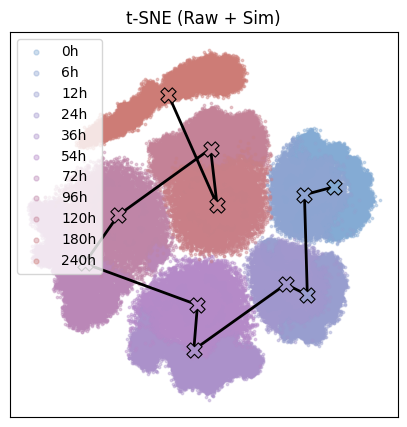

In [6]:
plot_tsne_with_labels(Z_combined,labels_time_combined,title='t-SNE (Raw + Sim)',
    size=3,alpha=0.4,max_points_per_label=10000,combined=True,
    save_path=None)

## Step 3: Pairwise distance curves

For each cell-type pair, compute Euclidean distance between latent centroids
at each timepoint. &nbsp; Raw + sim interleaved into an 11-point curve
(0h → 240h) with three summary statistics: &nbsp; *delta*, *std*, *slope*.

In [7]:
time_order_raw_idx = [0,2,4,6,8,10]
time_order_sim_idx = [1,3,5,7,9]

z_all_sim = sim_data["z_all"]
labels_time_sim = np.array(sim_data["labels_time_all"])
labels_celltype_sim = np.array(sim_data["labels_celltype_all"])

labels_time_raw = np.array(raw_data["labels_time_all"])
labels_celltype_raw = np.array(raw_data["labels_celltype_all"])
z_all_raw  = raw_data["z_all"]

def compute_latent_centers(z, labels_time, labels_celltype):
    centers={}
    for t in np.unique(labels_time):
        for c in np.unique(labels_celltype):
            idx = np.where((labels_time==t) & (labels_celltype==c))[0]
            if len(idx)==0:
                continue
            centers[(t,c)] = z[idx].mean(dim=0)
    return centers
centers_raw = compute_latent_centers(z_all_raw,labels_time_raw,labels_celltype_raw)
centers_sim = compute_latent_centers(z_all_sim,labels_time_sim,labels_celltype_sim)
print(f'Raw centers: {len(centers_raw)}  |  Sim centers: {len(centers_sim)}')
def compute_pairwise_distance_curves(centers, time_order_idx):
    celltypes_list = sorted({c for(_,c)in centers.keys()})
    dist_curves = {}
    for c1,c2 in combinations(celltypes_list,2):
        curve = []
        for t in time_order_idx:
            if(t,c1)in centers and(t,c2)in centers:
                curve.append(torch.norm(centers[(t,c1)]-centers[(t,c2)]).item())
            else: curve.append(np.nan)
        dist_curves[(c1,c2)] = curve
    return dist_curves

dist_curves_raw = compute_pairwise_distance_curves(centers_raw,time_order_raw_idx)
dist_curves_sim = compute_pairwise_distance_curves(centers_sim,time_order_sim_idx)
print(f'Pairs — raw: {len(dist_curves_raw)}  |  sim: {len(dist_curves_sim)}')

Raw centers: 54  |  Sim centers: 45
Pairs — raw: 36  |  sim: 36


In [8]:
def compute_scores_from_curve(curve):
    curve = np.array(curve,dtype=float); curve = curve[~np.isnan(curve)]
    if len(curve)<2: return {'delta':np.nan,'std':np.nan,'slope':np.nan}
    return {'delta':curve.max()-curve.min(),'std':curve.std(),
            'slope':np.polyfit(np.arange(len(curve)),curve,1)[0]}

def build_score_table(dist_curves, tag, time_order_idx):
    rows = []
    for(c1,c2),curve in dist_curves.items():
        row = {'celltype_1':c1,'celltype_2':c2,'source':tag,**compute_scores_from_curve(curve)}
        for t,d in zip(time_order_idx,curve): row[f'{tag}_d_{t}'] = d
        rows.append(row)
    return pd.DataFrame(rows)
def merge_raw_sim_curves(df_raw, df_sim):
    merged_rows=[]
    for i,row_raw in df_raw.iterrows():
        c1,c2=row_raw.celltype_1,row_raw.celltype_2
        row_sim = df_sim[(df_sim.celltype_1==c1)&(df_sim.celltype_2==c2)]
        if row_sim.empty:
            continue
        row_sim=row_sim.iloc[0]
        merged_curve=[]
        # Raw + Sim 按时间 index 顺序
        for t in sorted(time_order_raw_idx + time_order_sim_idx):
            if t in time_order_raw_idx:
                merged_curve.append(row_raw[f"raw_d_{t}"])
            else:
                merged_curve.append(row_sim[f"sim_d_{t}"])
        merged_rows.append({
            "celltype_1":c1,
            "celltype_2":c2,
            "merged_curve":merged_curve,
            **compute_scores_from_curve(merged_curve)
        })
    return pd.DataFrame(merged_rows)

df_raw = build_score_table(dist_curves_raw,'raw',time_order_raw_idx)
df_sim = build_score_table(dist_curves_sim,'sim',time_order_sim_idx)
display(df_raw.head(3))
display(df_sim.head(3))
df_merged = merge_raw_sim_curves(df_raw, df_sim)
display(df_merged.head(3))


,celltype_1,celltype_2,source,delta,std,slope,raw_d_0,raw_d_2,raw_d_4,raw_d_6,raw_d_8,raw_d_10
0,Nb2,cathepsin_cells,raw,0.013940,0.004755,-0.000024,0.023034,0.021778,0.015627,0.029567,0.016052,0.023513
1,Nb2,epidermal,raw,0.011257,0.004092,-0.000948,0.015529,0.009204,0.020461,0.014235,0.009210,0.010134
2,Nb2,gut,raw,0.011493,0.003705,-0.001368,0.026539,0.032840,0.024606,0.028988,0.024073,0.021346


,celltype_1,celltype_2,source,delta,std,slope,sim_d_1,sim_d_3,sim_d_5,sim_d_7,sim_d_9
0,Nb2,cathepsin_cells,sim,0.082164,0.026951,0.005001,0.154525,0.164305,0.103921,0.151194,0.186084
1,Nb2,epidermal,sim,0.089590,0.034158,-0.021030,0.180172,0.164177,0.113149,0.090581,0.111821
2,Nb2,gut,sim,0.082331,0.027965,0.014320,0.160851,0.161860,0.137905,0.186290,0.220237


,celltype_1,celltype_2,merged_curve,delta,std,slope
0,Nb2,cathepsin_cells,"[0.023033970966935158, 0.15452457964420319, 0....",0.170457,0.067521,0.000902
1,Nb2,epidermal,"[0.015529124066233635, 0.18017150461673737, 0....",0.170967,0.063574,-0.004125
2,Nb2,gut,"[0.026538586243987083, 0.1608506441116333, 0.0...",0.198890,0.075649,0.002168


## Step 4: Distance visualisation

Four modalities: &nbsp; **heatmaps** (per-timepoint distance matrix),
**river plots** (focal cell type vs. all others, PCHIP-smoothed)

In [9]:
outdir = os.path.join(RESULTS_DIR, 'celltype_distance_heatmaps')
os.makedirs(outdir, exist_ok=True)

celltypes = sorted(set(df_raw['celltype_1']) | set(df_raw['celltype_2']))
celltype2idx = {c: i for i, c in enumerate(celltypes)}
n_ct = len(celltypes)

# —— Heatmaps: raw (6 panels) + sim (5 panels) separately ——
for tag, df, time_idx in [('raw', df_raw, time_order_raw_idx), 
                           ('sim', df_sim, time_order_sim_idx)]:
    for t in time_idx:
        # ---------- 构建距离矩阵 ----------
        mat = np.full((n_ct, n_ct), np.nan)
        
        for _, row in df.iterrows():
            d = row[f'{tag}_d_{t}']
            if not np.isnan(d):
                i, j = celltype2idx[row['celltype_1']], celltype2idx[row['celltype_2']]
                mat[i, j] = mat[j, i] = d
        
        np.fill_diagonal(mat, 0.0)
        
        # ---------- 每个时间点单独归一化 ----------
        mask = ~np.eye(n_ct, dtype=bool)
        valid = mat[mask & ~np.isnan(mat)]
        
        if len(valid) > 0:
            vmin, vmax = valid.min(), valid.max()
            if vmax > vmin:
                mat[mask] = (mat[mask] - vmin) / (vmax - vmin)
            else:
                mat[mask] = 0.0
            
            # 距离物理约束（确保非负）
            mat[mask] = np.abs(mat[mask])
        
        np.fill_diagonal(mat, 0.0)
        
        # ---------- 绘制热图 ----------
        mat_d = pd.DataFrame(mat,
                            index=[celltypes2names[c] for c in celltypes],
                            columns=[celltypes2names[c] for c in celltypes])
        
        plt.figure(figsize=(7, 6))
        sns.heatmap(mat_d, 
                    cmap='viridis', 
                    square=True, 
                    linewidths=0.3, 
                    linecolor='white', 
                    vmin=0, 
                    vmax=1,
                    cbar_kws={'label': 'Normalized Latent Distance (per time point)'})
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.yticks(fontsize=12)
        plt.title(f'{id2time[t]} ({tag})')
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f'heatmap_{tag}_t{t}_{id2time[t]}.pdf'), dpi=300)
        plt.close()

print('Heatmaps done with per-time-point normalization.')

Heatmaps done with per-time-point normalization.


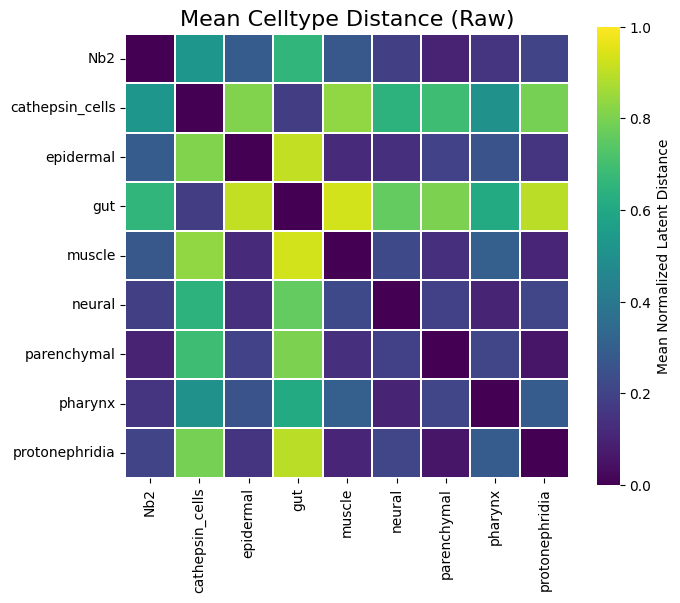

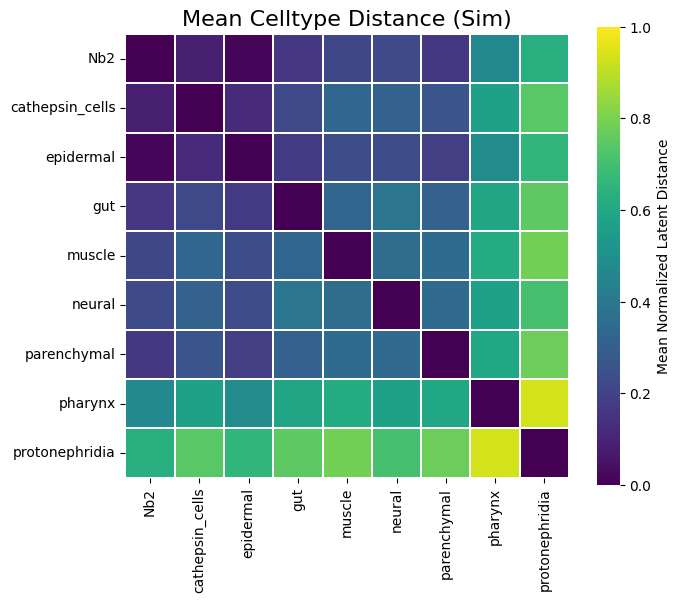

完成：raw 和 sim 全时期归一化热图已生成


In [10]:

celltype2idx = {c: i for i, c in enumerate(celltypes)}
n_ct = len(celltypes)

# 所有时间点数量（取最长曲线长度）
time_all_raw = max(len(v) for v in dist_curves_raw.values())
time_all_sim = max(len(v) for v in dist_curves_sim.values())
time_all = max(time_all_raw, time_all_sim)
time_points = list(range(time_all))

# 输出文件夹
outdir = os.path.join(RESULTS_DIR, 'celltype_distance_heatmaps')

# ===============================
# 2. 计算全时期平均矩阵函数
# ===============================
def compute_mean_norm_matrix(dist_curves, celltypes, celltype2idx, time_points):
    """
    dist_curves: dict[(cell1, cell2)] -> list[float]
    返回：平均归一化矩阵 DataFrame (celltype x celltype)
    """
    n_ct = len(celltypes)
    time2mat_norm = {}

    # 每个时间点构建矩阵并归一化
    for t in time_points:
        mat = np.full((n_ct, n_ct), np.nan)

        for (c1, c2), curve in dist_curves.items():
            if t >= len(curve):
                continue
            d = curve[t]
            if np.isnan(d):
                continue
            i, j = celltype2idx[c1], celltype2idx[c2]
            mat[i, j] = d
            mat[j, i] = d

        # 对角线 = 0
        np.fill_diagonal(mat, 0.0)

        # 每个时期单独归一化（只对非对角线、非 NaN）
        mask = ~np.eye(n_ct, dtype=bool)
        valid = mat[mask & ~np.isnan(mat)]
        if len(valid) > 0:
            vmin, vmax = valid.min(), valid.max()
            if vmax > vmin:
                mat[mask] = (mat[mask] - vmin) / (vmax - vmin)
            else:
                mat[mask] = 0.0

        np.fill_diagonal(mat, 0.0)
        time2mat_norm[t] = pd.DataFrame(mat, index=celltypes, columns=celltypes)

    # 堆叠所有时间点矩阵，沿时间取平均
    stack = np.stack([mat.values for mat in time2mat_norm.values()], axis=0)
    mean_mat = np.nanmean(stack, axis=0)
    np.fill_diagonal(mean_mat, 0.0)

    mean_df = pd.DataFrame(mean_mat, index=celltypes, columns=celltypes)
    return mean_df

# ===============================
# 3. 绘制函数
# ===============================
def plot_heatmap(df, title, outpath=None):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        df,
        cmap="viridis",
        square=True,
        linewidths=0.3,
        linecolor="white",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Mean Normalized Latent Distance"}
    )
    plt.title(title, fontsize=16)
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    if outpath is not None:
        plt.savefig(outpath, dpi=300)
        plt.show()
        plt.close()
    else:
        plt.show()

# ===============================
# 4. 生成 raw 和 sim 的全时期平均热图
# ===============================
mean_raw_df = compute_mean_norm_matrix(dist_curves_raw, celltypes, celltype2idx, time_points)
mean_sim_df = compute_mean_norm_matrix(dist_curves_sim, celltypes, celltype2idx, time_points)

plot_heatmap(
    mean_raw_df,
    "Mean Celltype Distance (Raw)",
    outpath=f"{outdir}/celltype_distance_heatmap_mean_all_stages_raw_norm.pdf"
)

plot_heatmap(
    mean_sim_df,
    "Mean Celltype Distance (Sim)",
    outpath=f"{outdir}/celltype_distance_heatmap_mean_all_stages_sim_norm.pdf"
)

print("完成：raw 和 sim 全时期归一化热图已生成")


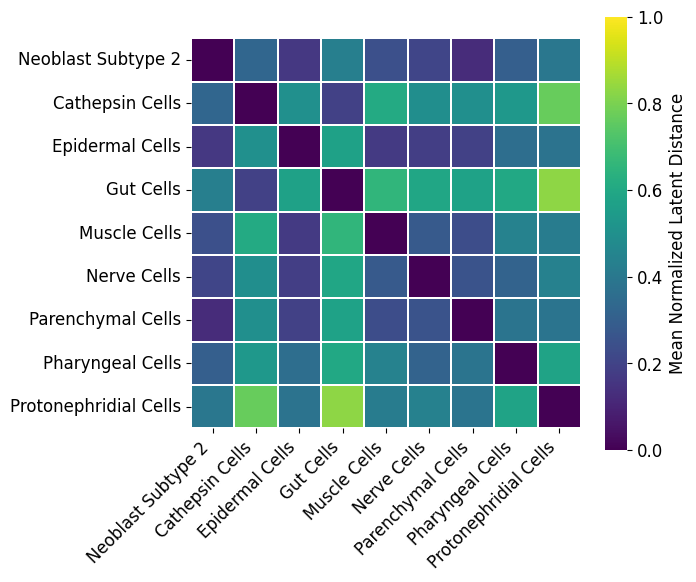

In [11]:

# time → DataFrame(celltype × celltype)
time2mat = {}
time_all = list(range(11))  # 0–10
for t in time_all:
    mat = np.full((n_ct, n_ct), np.nan)

    for _, row in df_merged.iterrows():
        d = row["merged_curve"][t]
        if np.isnan(d):
            continue

        i = celltype2idx[row["celltype_1"]]
        j = celltype2idx[row["celltype_2"]]
        mat[i, j] = d
        mat[j, i] = d

    np.fill_diagonal(mat, 0.0)

    time2mat[t] = pd.DataFrame(
        mat,
        index=celltypes,
        columns=celltypes
    )

for t, mat in time2mat.items():

    # ---------- 1. 数值处理（完全不动逻辑） ----------
    mat_vals = mat.values.copy()

    mask = ~np.eye(mat_vals.shape[0], dtype=bool)
    valid = mat_vals[mask & ~np.isnan(mat_vals)]

    if len(valid) > 0:
        vmin, vmax = valid.min(), valid.max()
        if vmax > vmin:
            mat_vals[mask] = (mat_vals[mask] - vmin) / (vmax - vmin)
        else:
            mat_vals[mask] = 0.0

        # 距离的物理约束
        mat_vals[mask] = np.abs(mat_vals[mask])

    np.fill_diagonal(mat_vals, 0.0)

    mat_norm = pd.DataFrame(
        mat_vals,
        index=mat.index,
        columns=mat.columns
    )
    

    # ---------- 2. 仅用于展示的名称映射 ----------
    display_index = [celltypes2names.get(c, c) for c in mat_norm.index]
    display_columns = [celltypes2names.get(c, c) for c in mat_norm.columns]

    mat_display = mat_norm.copy()
    mat_display.index = display_index
    mat_display.columns = display_columns

    # ---------- 3. 绘图 ----------
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        mat_display,
        cmap="viridis",
        square=True,
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "Normalized Latent Distance"},
        vmin=0,
        vmax=1
    )

    # plt.title(
    #     f"Celltype Distance at {id2time[t]} (Normalized)",
    #     fontsize=16
    # )

    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()
    plt.savefig(
        f"{outdir}/celltype_distance_heatmap_t{t}_{id2time[t]}_norm_9999.pdf",
        dpi=300
    )
    plt.close()

time2mat_norm = {}

for t in time_all:
    mat = np.full((n_ct, n_ct), np.nan)

    # ---------- 构建距离矩阵 ----------
    for _, row in df_merged.iterrows():
        d = row["merged_curve"][t]
        if np.isnan(d):
            continue

        i = celltype2idx[row["celltype_1"]]
        j = celltype2idx[row["celltype_2"]]
        mat[i, j] = d
        mat[j, i] = d

    np.fill_diagonal(mat, 0.0)

    # ---------- 每个时期单独归一化 ----------
    mask = ~np.eye(n_ct, dtype=bool)
    valid = mat[mask & ~np.isnan(mat)]

    if len(valid) > 0:
        vmin, vmax = valid.min(), valid.max()
        if vmax > vmin:
            mat[mask] = (mat[mask] - vmin) / (vmax - vmin)
        else:
            mat[mask] = 0.0

        # 距离物理约束
        mat[mask] = np.abs(mat[mask])
        

    np.fill_diagonal(mat, 0.0)

    time2mat_norm[t] = pd.DataFrame(
        mat,
        index=celltypes,    # ⚠️ 原始 key
        columns=celltypes
    )

# ---------- 所有时期求平均 ----------
stack = np.stack(
    [mat.values for mat in time2mat_norm.values()],
    axis=0
)

mean_mat = np.nanmean(stack, axis=0)

mean_df = pd.DataFrame(
    mean_mat,
    index=celltypes,      # ⚠️ 原始 key
    columns=celltypes
)

np.fill_diagonal(mean_df.values, 0.0)

# ---------- 仅用于展示的名称映射 ----------
display_index = [celltypes2names.get(c, c) for c in mean_df.index]
display_columns = [celltypes2names.get(c, c) for c in mean_df.columns]

mean_df_display = mean_df.copy()
mean_df_display.index = display_index
mean_df_display.columns = display_columns

# ---------- 绘图 ----------
plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    mean_df_display,
    cmap="viridis",
    square=True,
    linewidths=0.3,
    linecolor="white",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean Normalized Latent Distance (All Stages)"}
)

# plt.title(
#     "Mean Celltype Distance (Raw + Sim)",
#     fontsize=16
# )
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)
# 调整 colorbar 字体
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Mean Normalized Latent Distance", fontsize=12)
plt.tight_layout()
plt.savefig(
    f"{outdir}/celltype_distance_heatmap_mean_all_stages.pdf",
    dpi=300
)
plt.show()
plt.close()

## Step 5: Generate Riverplots

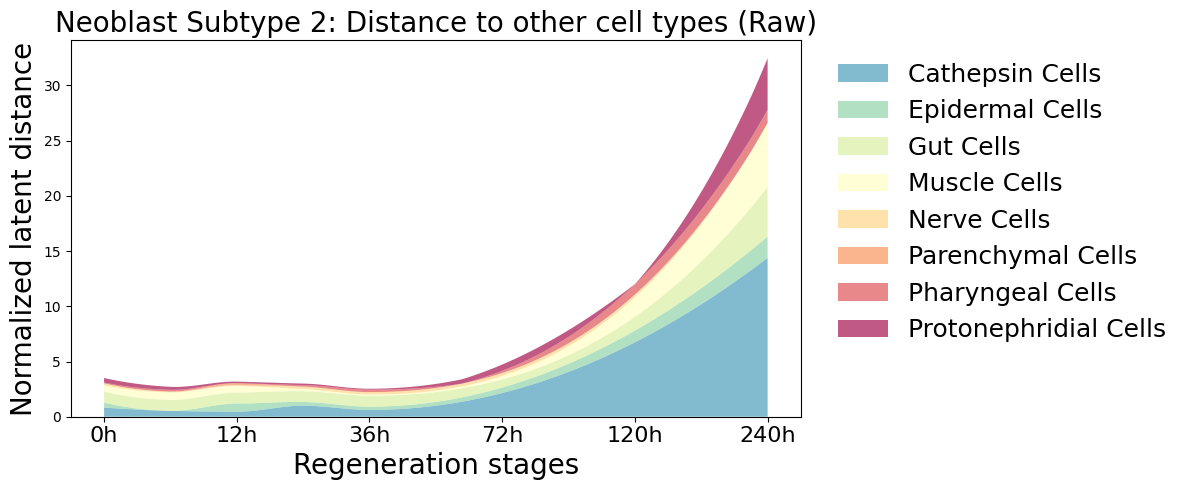

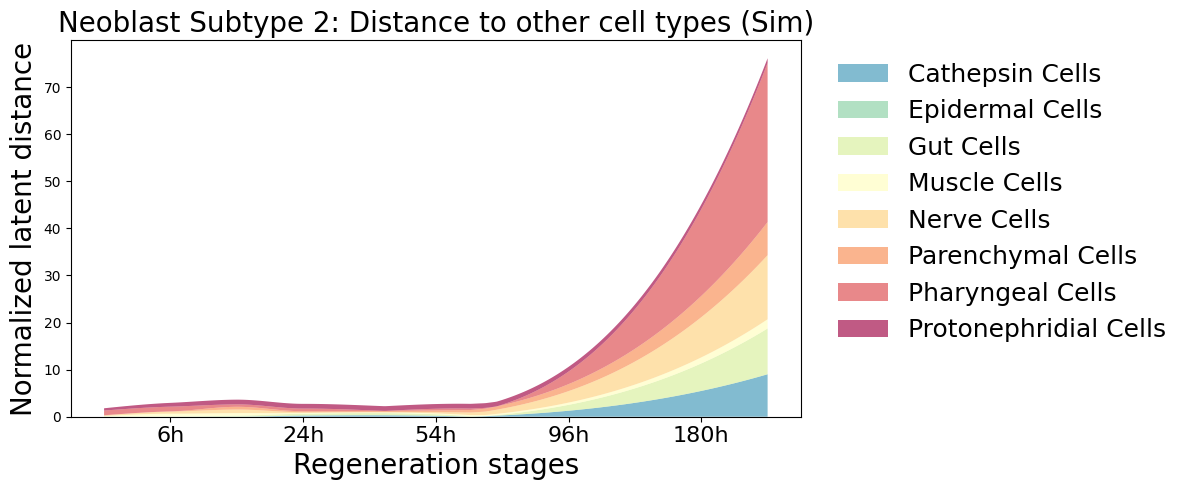

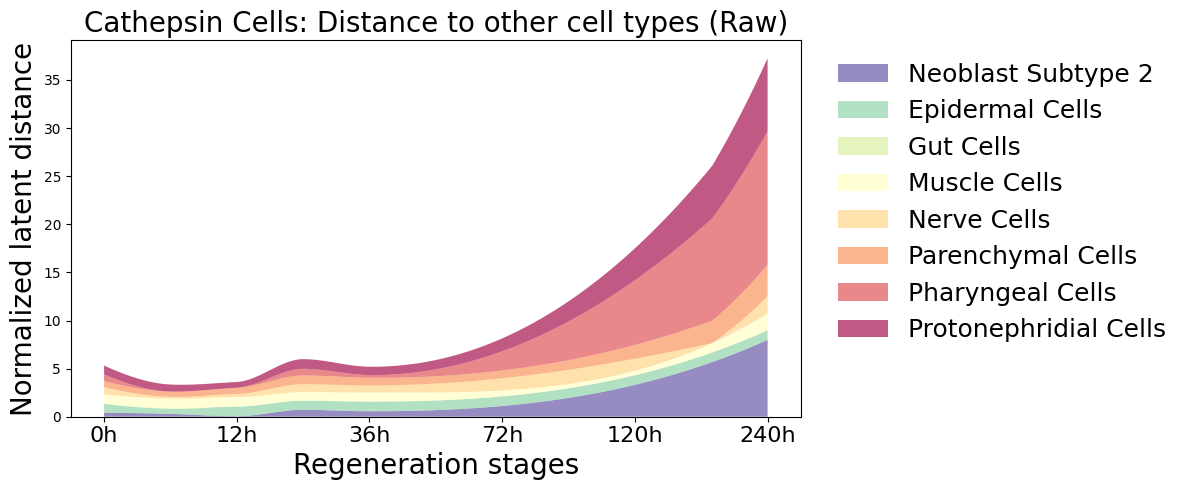

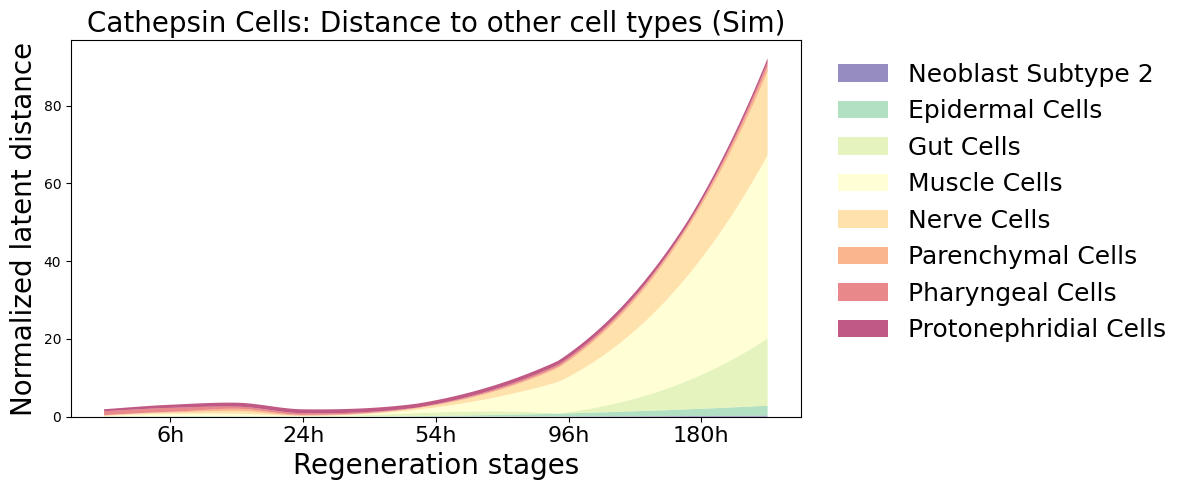

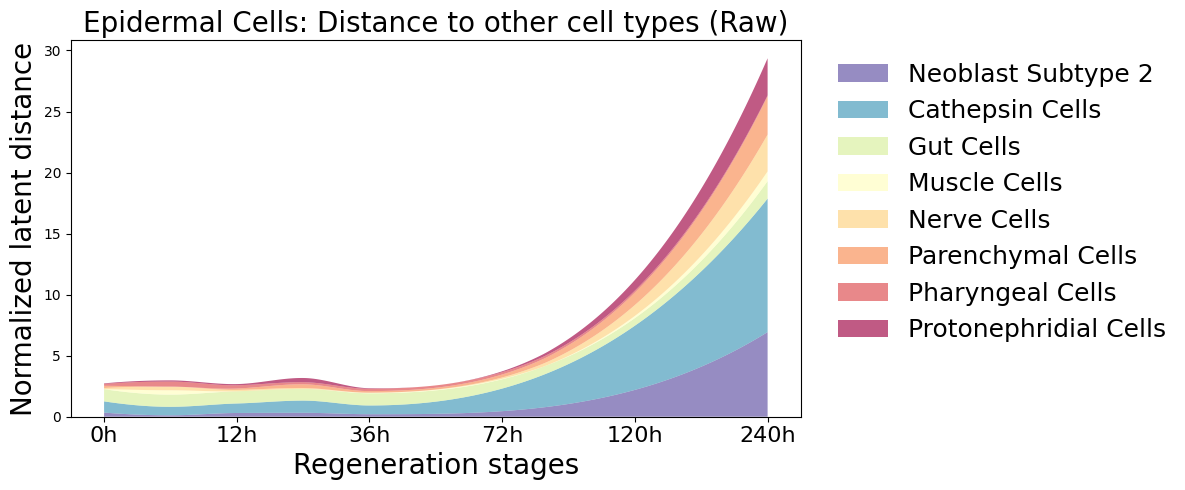

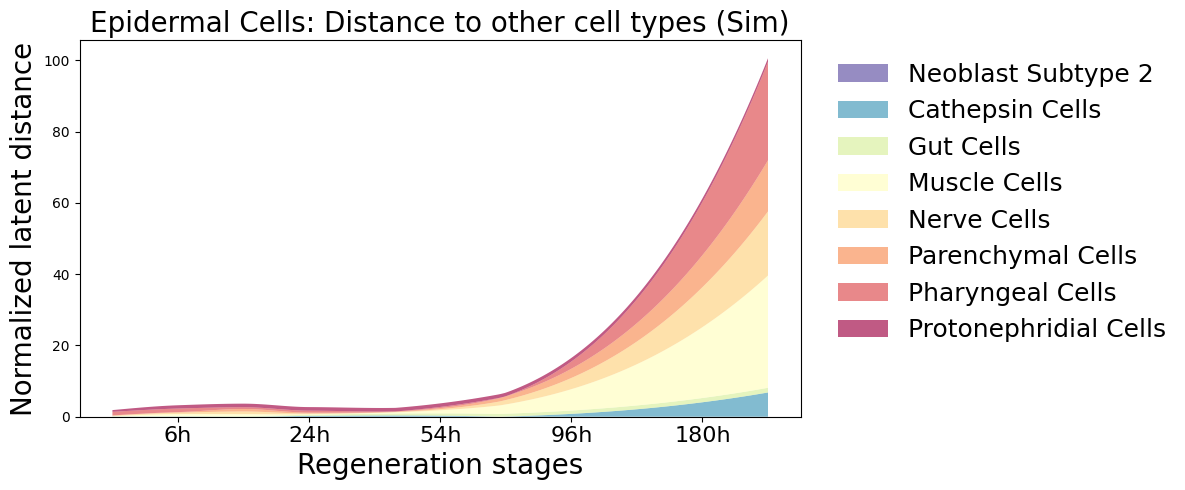

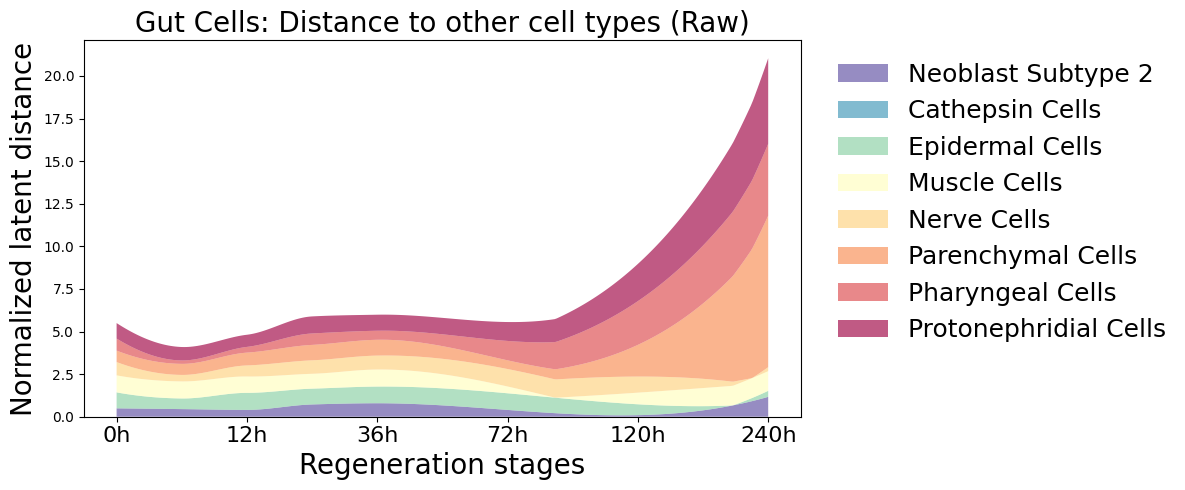

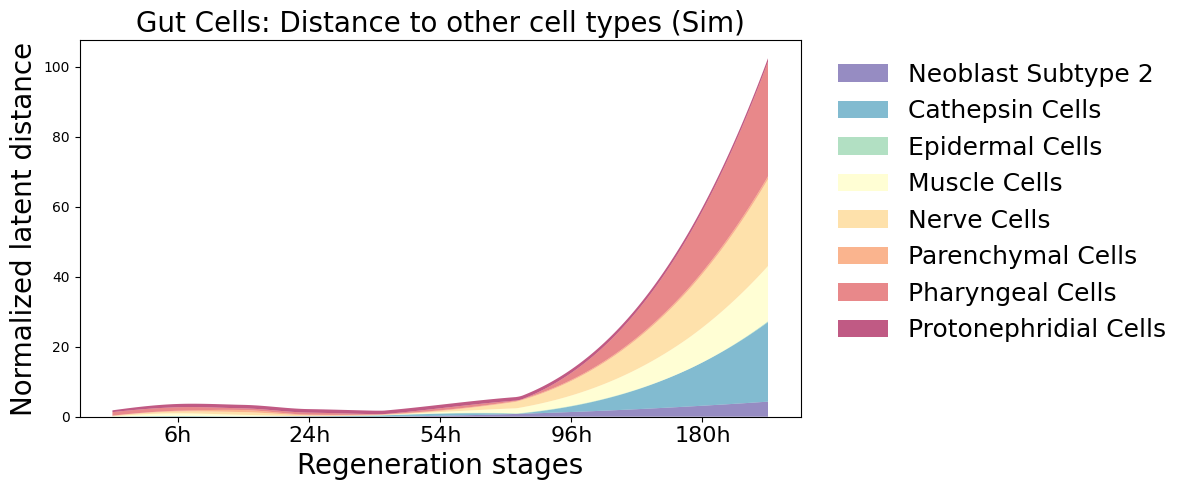

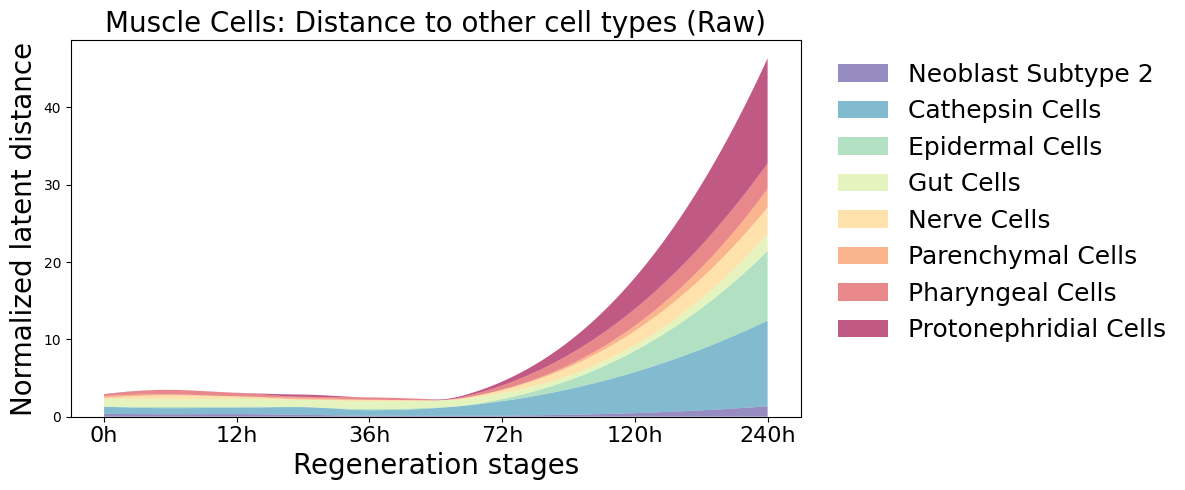

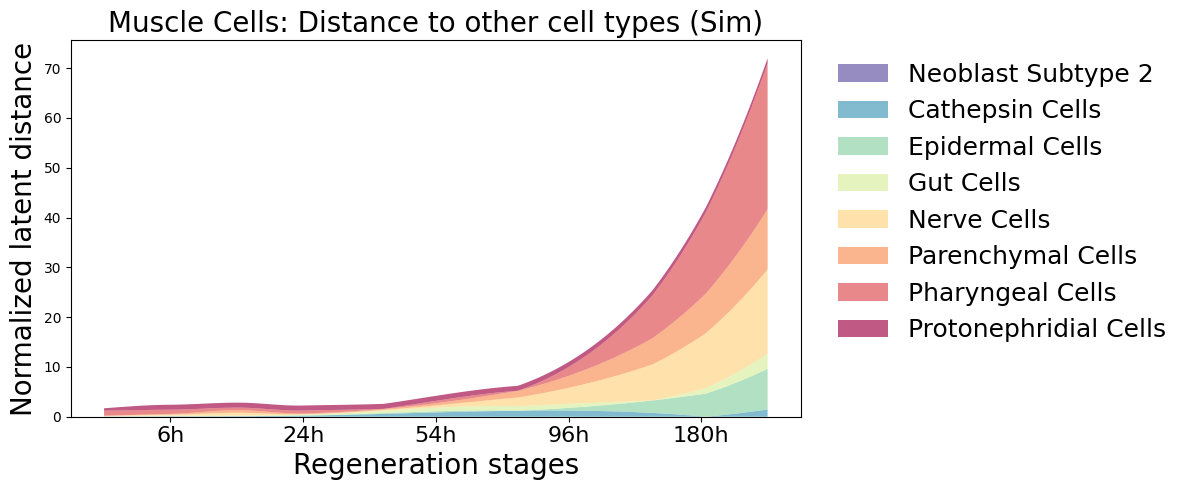

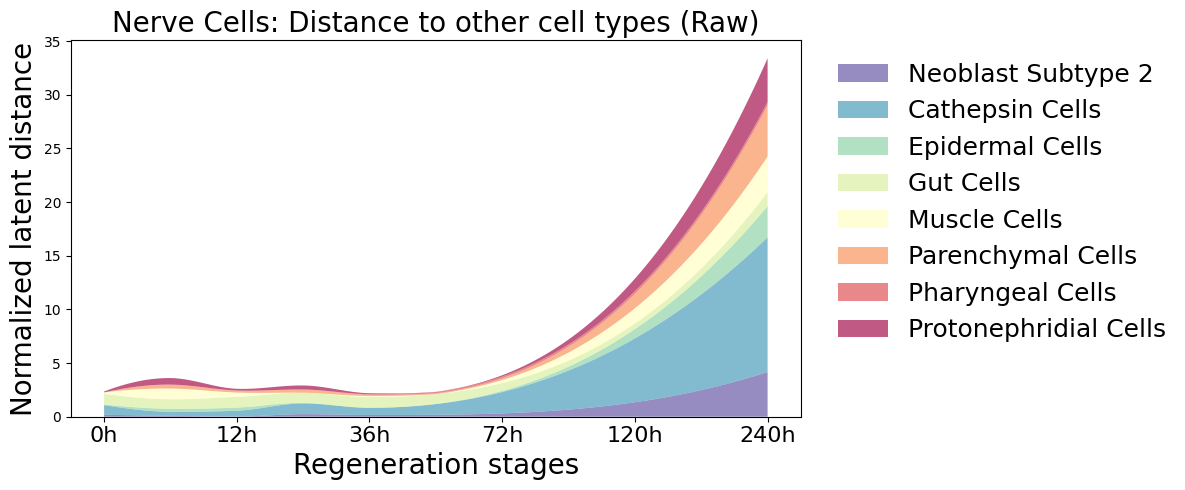

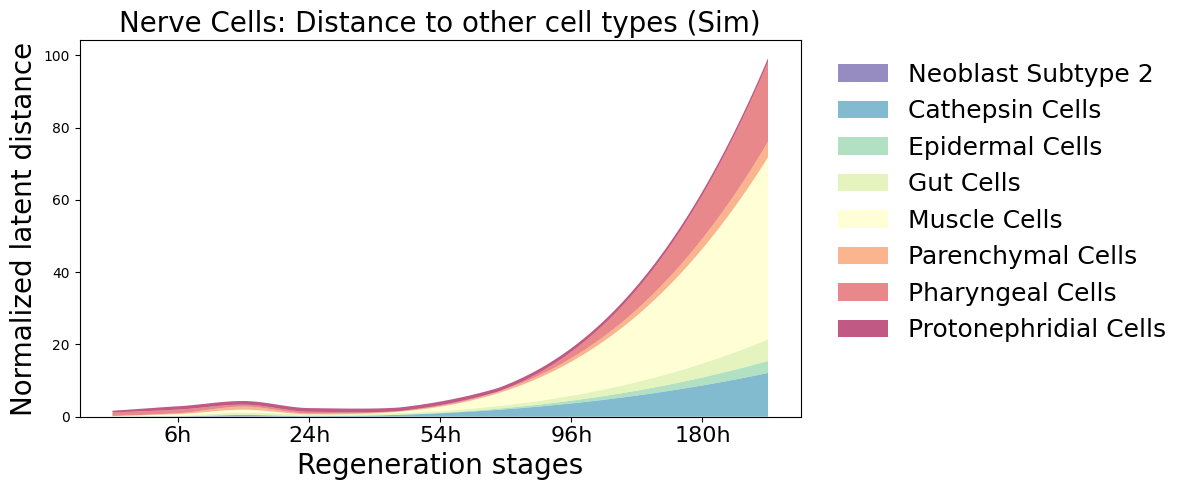

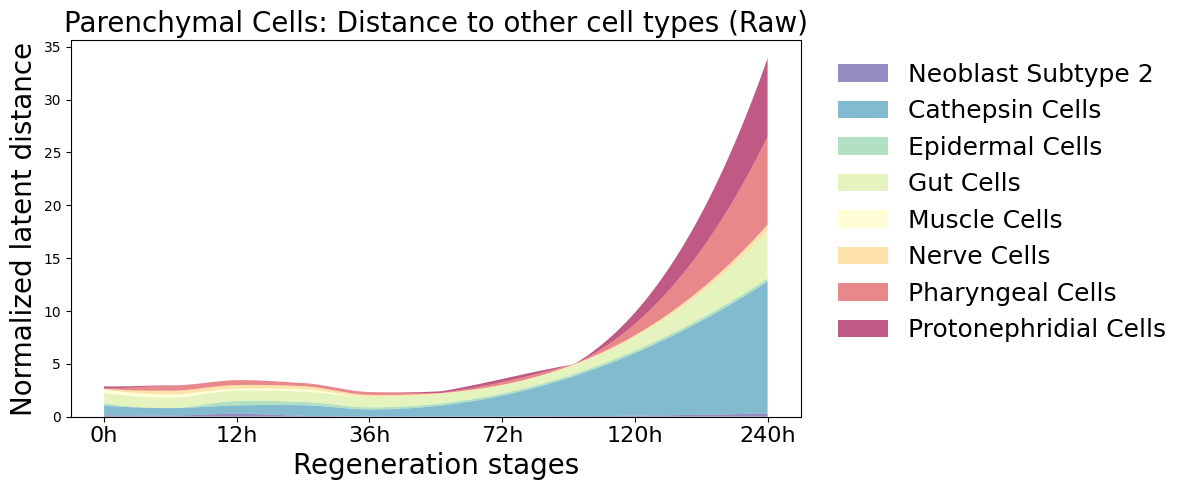

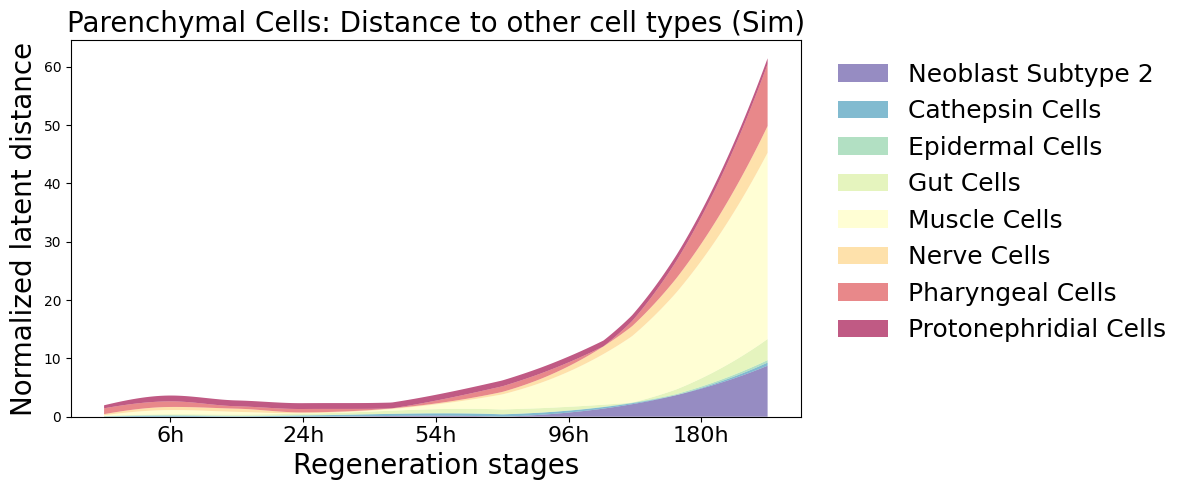

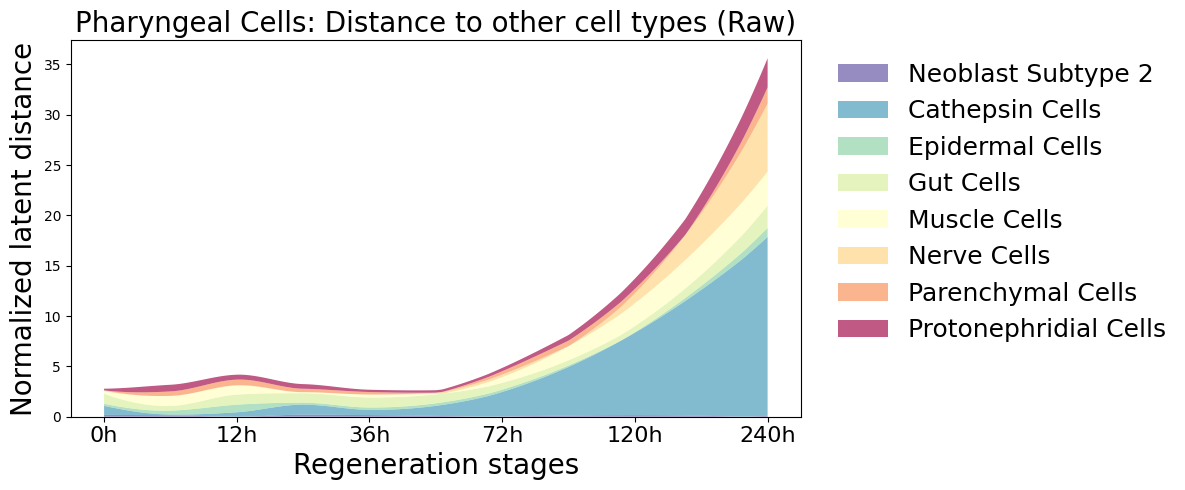

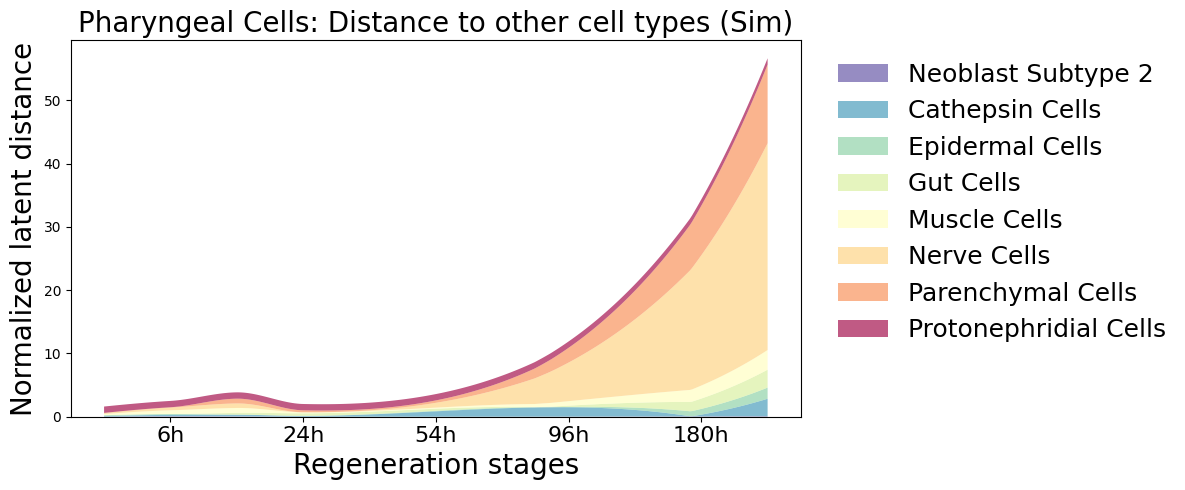

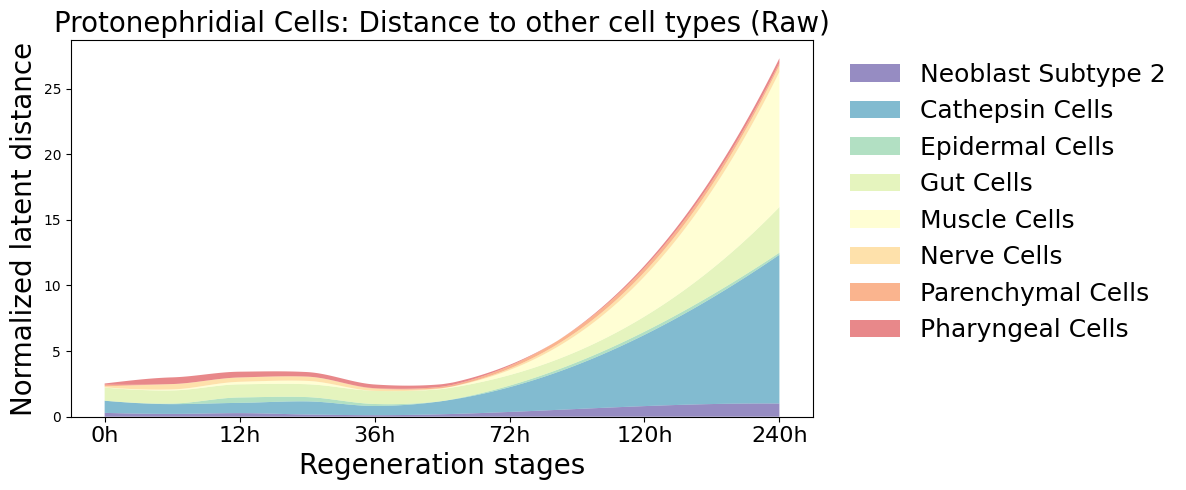

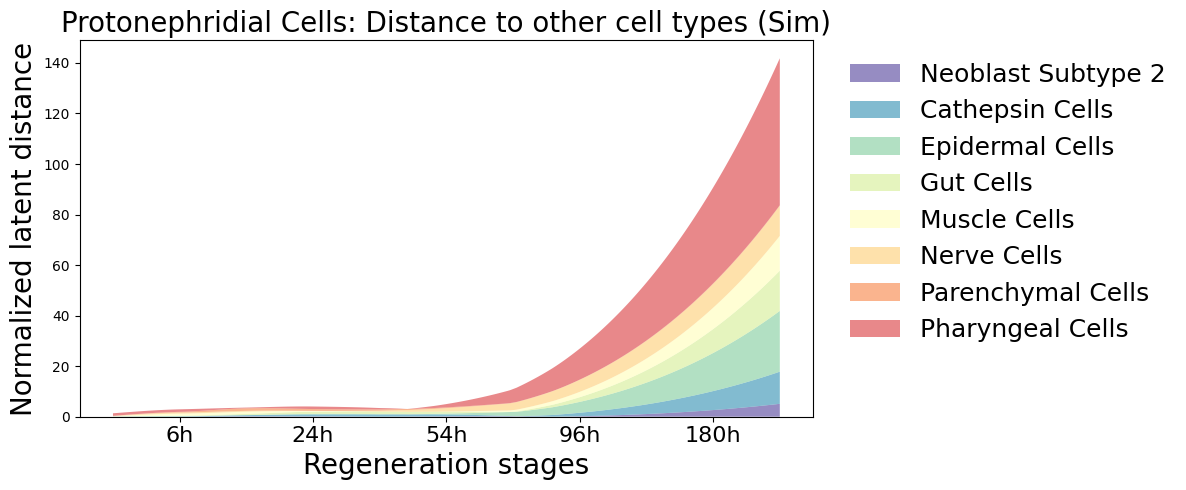

In [12]:
def plot_celltype_river_separate(celltype, curve_dict, outdir, title_prefix="Raw"):
    """
    绘制单个 celltype 的河流图 (Raw 或 Sim)
    """

    # 1️⃣ 找到其他所有 cell types（原始 key）
    others = sorted({
        c2 if c1 == celltype else c1
        for (c1, c2) in curve_dict.keys()
        if c1 == celltype or c2 == celltype
    })

    # 2️⃣ 构建 时间 × 其他 cell type 矩阵（仍用 key）
    mat = pd.DataFrame(index=others, columns=time_all, dtype=float)

    for c_other in others:
        if (celltype, c_other) in curve_dict:
            curve = np.array(curve_dict[(celltype, c_other)], dtype=float)
        elif (c_other, celltype) in curve_dict:
            curve = np.array(curve_dict[(c_other, celltype)], dtype=float)
        else:
            continue

        for t_idx, d in enumerate(curve):
            if t_idx not in time_all or np.isnan(d):
                continue
            mat.loc[c_other, t_idx] = d

    # 3️⃣ 每个时间点归一化（距离 → 非负）
    mat_norm = mat.copy()
    for t in time_all:
        col = np.abs(mat[t].values.astype(float))

        if np.all(np.isnan(col)):
            continue
        vmin, vmax = np.nanmin(col), np.nanmax(col)
        if vmax > vmin:
            mat_norm[t] = (col - vmin) / (vmax - vmin)
        else:
            mat_norm[t] = 0.0
    mat_norm = mat_norm.abs()

    # 4️⃣ 平滑时间轴（不再做人为裁剪）
    x = np.array(time_all, dtype=float)
    x_smooth = np.linspace(x.min(), x.max(), 300)
    smooth_layers = []

    for _, row in mat_norm.iterrows():
        y = row.values.astype(float)
        mask = ~np.isnan(y)
        if mask.sum() < 3:
            smooth_layers.append(np.zeros_like(x_smooth))
            continue

        f = PchipInterpolator(x[mask], y[mask])
        smooth_layers.append(f(x_smooth))

    smooth_layers = np.vstack(smooth_layers)
    smooth_layers = np.abs(smooth_layers)

    # ===============================
    # ⭐ 关键修改：展示名在这里处理
    # ===============================
    others_display = [celltypes2names.get(c, c) for c in others]
    celltype_display = celltypes2names.get(celltype, celltype)

    # 5️⃣ 绘图
    plt.figure(figsize=(12, 5))
    colors = [celltype2color[c] for c in others]

    plt.stackplot(
        x_smooth,
        smooth_layers,
        colors=colors,
        alpha=0.65,
        linewidth=0
    )

    plt.xlabel("Regeneration stages", fontsize=20)
    plt.ylabel("Normalized latent distance", fontsize=20)
    plt.title(
        f"{celltype_display}: Distance to other cell types ({title_prefix})",
        fontsize=20
    )
    if(title_prefix == 'Raw'):
        time_all_sub = time_all[0::2]
    else:
        time_all_sub = time_all[1::2]
    time_all_names = [id2time[t] for t in time_all_sub]
    plt.xticks(ticks=time_all_sub, labels=time_all_names, fontsize=16)

    plt.legend(
        others_display,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=18,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(
        f"{outdir}/{celltype}_distance_riverplot_{title_prefix.lower()}.pdf",
        dpi=300
    )
    plt.show()
    plt.close()
outdir = os.path.join(RESULTS_DIR, 'celltype_distance_riverplots')
for c in celltypes:
    plot_celltype_river_separate(c, dist_curves_raw, outdir, title_prefix="Raw")
    plot_celltype_river_separate(c, dist_curves_sim, outdir, title_prefix="Sim")

['Nb2', 'cathepsin_cells', 'epidermal', 'gut', 'muscle', 'neural', 'parenchymal', 'pharynx', 'protonephridia']
{'Neoblast Subtype 2': 'Nb2', 'Cathepsin Cells': 'cathepsin_cells', 'Epidermal Cells': 'epidermal', 'Gut Cells': 'gut', 'Muscle Cells': 'muscle', 'Nerve Cells': 'neural', 'Parenchymal Cells': 'parenchymal', 'Pharyngeal Cells': 'pharynx', 'Protonephridial Cells': 'protonephridia'}
{'Nb2': (0.3686274509803922, 0.30980392156862746, 0.6352941176470588, 1.0), 'cathepsin_cells': (0.24805843906189934, 0.5913110342176087, 0.7171856978085351, 1.0), 'epidermal': (0.5379469434832758, 0.8147635524798155, 0.6450595924644368, 1.0), 'gut': (0.8475201845444063, 0.9386389850057671, 0.6071510957324106, 1.0), 'muscle': (0.9999231064975009, 0.9976163014225298, 0.7450211457131872, 1.0), 'neural': (0.9950019223375625, 0.8246059207996924, 0.4998846597462514, 1.0), 'parenchymal': (0.9734717416378317, 0.5474048442906574, 0.31810841983852367, 1.0), 'pharynx': (0.8615148019992311, 0.2828911956939638, 0.

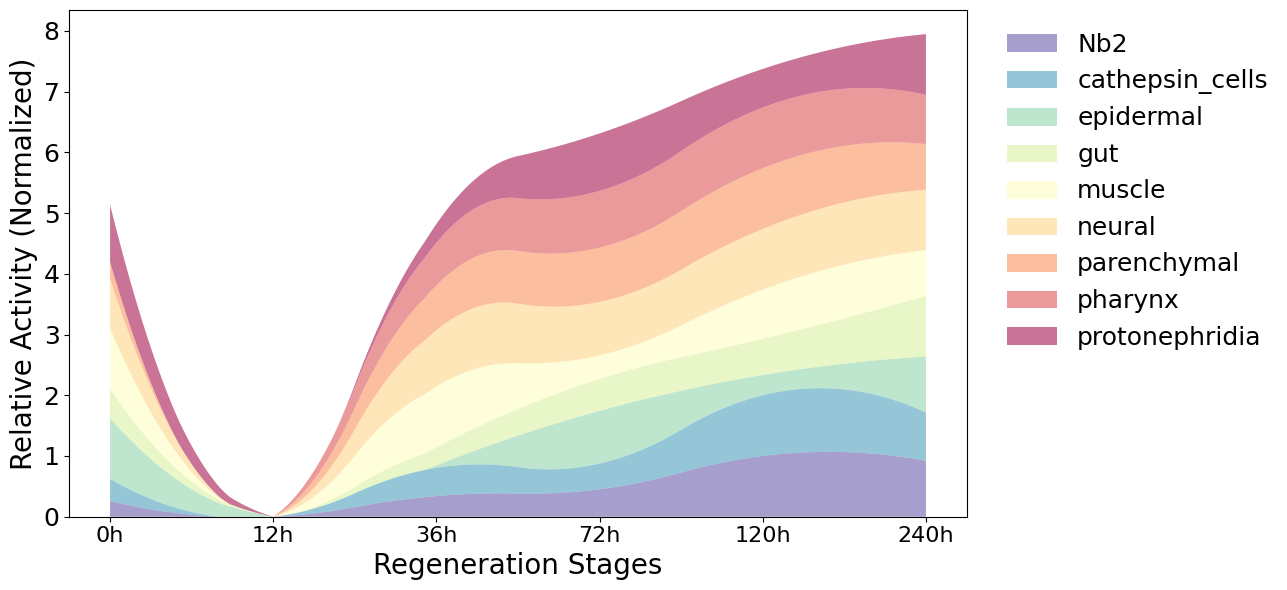

['Nb2', 'cathepsin_cells', 'epidermal', 'gut', 'muscle', 'neural', 'parenchymal', 'pharynx', 'protonephridia']
{'Neoblast Subtype 2': 'Nb2', 'Cathepsin Cells': 'cathepsin_cells', 'Epidermal Cells': 'epidermal', 'Gut Cells': 'gut', 'Muscle Cells': 'muscle', 'Nerve Cells': 'neural', 'Parenchymal Cells': 'parenchymal', 'Pharyngeal Cells': 'pharynx', 'Protonephridial Cells': 'protonephridia'}
{'Nb2': (0.3686274509803922, 0.30980392156862746, 0.6352941176470588, 1.0), 'cathepsin_cells': (0.24805843906189934, 0.5913110342176087, 0.7171856978085351, 1.0), 'epidermal': (0.5379469434832758, 0.8147635524798155, 0.6450595924644368, 1.0), 'gut': (0.8475201845444063, 0.9386389850057671, 0.6071510957324106, 1.0), 'muscle': (0.9999231064975009, 0.9976163014225298, 0.7450211457131872, 1.0), 'neural': (0.9950019223375625, 0.8246059207996924, 0.4998846597462514, 1.0), 'parenchymal': (0.9734717416378317, 0.5474048442906574, 0.31810841983852367, 1.0), 'pharynx': (0.8615148019992311, 0.2828911956939638, 0.

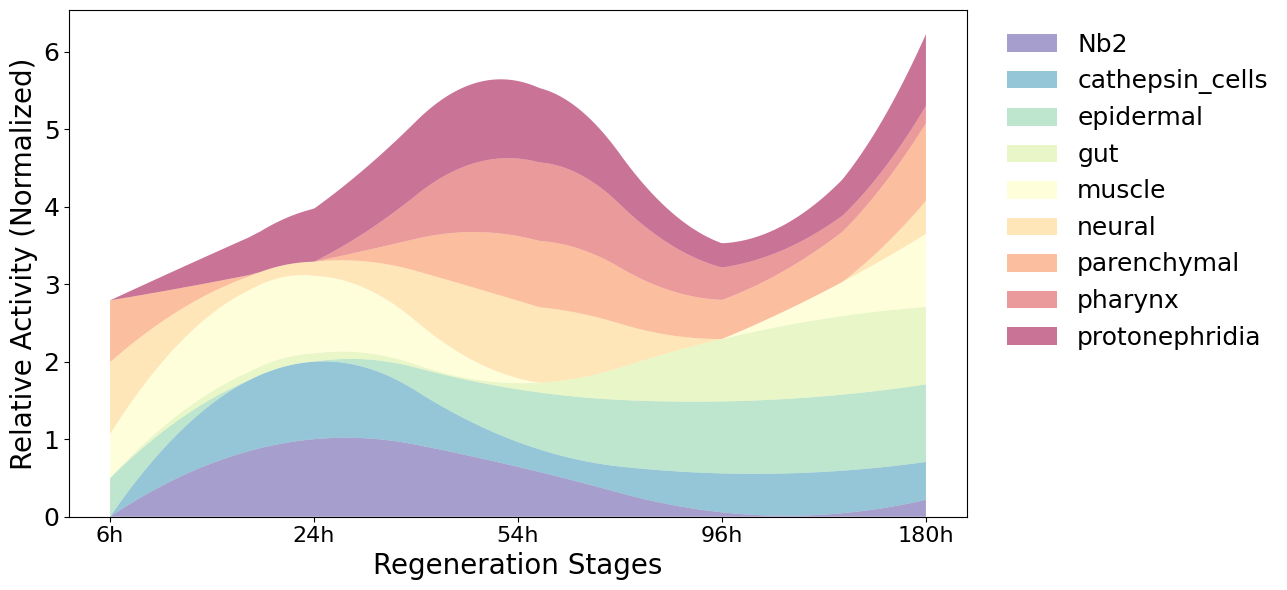

In [13]:

def smooth_stackplot_pretty(
    time_points,
    expr_norm_df,
    title,
    outpath,
    n_interp=300,
    cmap_name="Spectral_r"
):
    x = np.array(time_points)
    x_smooth = np.linspace(x.min(), x.max(), n_interp)

    celltypes = expr_norm_df.columns.tolist()
    # n_ct = len(celltypes)

    # 颜色
    # cmap = plt.get_cmap(cmap_name)
    # colors = [cmap(i / (n_ct - 1)) for i in range(n_ct)]
    print(celltypes)
    print(cellnames2types)
    print(celltype2color)
    colors = [celltype2color[c] for c in celltypes]


    smooth_layers = []

    for c in celltypes:
        y = expr_norm_df[c].values.astype(float)

        if np.all(np.isnan(y)) or np.nanmax(y) == 0:
            smooth_layers.append(np.zeros_like(x_smooth))
            continue

        y = np.nan_to_num(y)
        spline = make_interp_spline(x, y, k=2)
        y_smooth = spline(x_smooth)
        y_smooth[y_smooth < 0] = 0
        smooth_layers.append(y_smooth)

    smooth_layers = np.array(smooth_layers)

    # ======= 绘图 =======
    plt.figure(figsize=(13, 6))

    plt.stackplot(
        x_smooth,
        smooth_layers,
        labels=celltypes,
        colors=colors,
        alpha=0.55,        # 🔑 关键
        linewidth=0        # 🔑 去掉边缘线
    )

    plt.xlabel("Regeneration Stages", fontsize=20)
    plt.ylabel("Relative Activity (Normalized)", fontsize=20)
    # plt.title(title, fontsize=20)
    time_points_names = [id2time[time_id] for time_id in time_points]
    plt.xticks(ticks=time_points, labels=time_points_names, fontsize=16)
    plt.yticks(fontsize=18)

    plt.grid(False)

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=18,
        frameon=False,
        ncol=1
    )

    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.show()
    plt.close()

# ------------------ 5. 每列归一化 ------------------
def normalize_df_per_column_by_time(df):
    df_norm = df.copy()
    for c in df.columns:
        s = df[c].astype(float)
        valid = s.notna()
        if valid.sum() < 2:
            df_norm[c] = np.nan
            continue
        vmin, vmax = s[valid].min(), s[valid].max()
        if vmax > vmin:
            df_norm.loc[valid, c] = (s[valid] - vmin) / (vmax - vmin)
        else:
            df_norm.loc[valid, c] = np.nan
        df_norm.loc[~valid, c] = np.nan
    return df_norm


# ------------------ 3. 加权平均表达函数 ------------------
def compute_weighted_mean_expr(x_all, labels_time, labels_celltype, time_points, celltypes, min_cells=50):
    expr_matrix = pd.DataFrame(index=time_points, columns=celltypes, dtype=float)
    for t in time_points:
        for c in celltypes:
            idx = np.where((labels_time == t) & (labels_celltype == c))[0]
            if len(idx) < min_cells:
                expr_matrix.loc[t, c] = np.nan
                continue
            x_cells = x_all[idx]
            cell_means = []
            weights = []
            for cell_expr in x_cells:
                nonzero_vals = cell_expr[cell_expr > 0]
                if len(nonzero_vals) > 0:
                    cell_means.append(nonzero_vals.mean().item())
                    weights.append(len(nonzero_vals))
            if len(cell_means) > 0:
                expr_matrix.loc[t, c] = np.average(cell_means, weights=weights)
            else:
                expr_matrix.loc[t, c] = np.nan
    return expr_matrix

# ----------------------------
# 2. 时间轴
# ----------------------------
time_raw = [0,2,4,6,8,10]
time_sim = [1,3,5,7,9]
x_all_sim = sim_data["x_all"]
labels_time_sim = np.array(sim_data["labels_time_all"])
labels_celltype_sim = np.array(sim_data["labels_celltype_all"])

x_all_raw = raw_data["x_all"]
labels_time_raw = np.array(raw_data["labels_time_all"])
labels_celltype_raw = np.array(raw_data["labels_celltype_all"])
time_points_raw = sorted(set(t for (t, _) in centers_raw.keys()))
time_points_sim = sorted(set(t for (t, _) in centers_sim.keys()))
# ------------------ 4. 计算 Raw / Sim 平均表达 ------------------
expr_raw = compute_weighted_mean_expr(x_all_raw, labels_time_raw, labels_celltype_raw, time_points_raw, celltypes)
expr_sim = compute_weighted_mean_expr(x_all_sim, labels_time_sim, labels_celltype_sim, time_points_sim, celltypes)
expr_raw_norm = normalize_df_per_column_by_time(expr_raw)
expr_sim_norm = normalize_df_per_column_by_time(expr_sim)
outdir = os.path.join(RESULTS_DIR, 'celltype_distance_riverplots')
smooth_stackplot_pretty(
    time_raw,
    expr_raw_norm,
    title="Temporal Activity of Celltypes (Raw)",
    outpath=os.path.join(outdir, "celltype_activity_raw_river_pretty.pdf"),
    cmap_name="Spectral_r"
)

smooth_stackplot_pretty(
    time_sim,
    expr_sim_norm,
    title="Temporal Activity of Celltypes (Simulated)",
    outpath=os.path.join(outdir, "celltype_activity_sim_river_pretty.pdf"),
    cmap_name="Spectral_r"
)
